### Hasbrouck VECM Model Fitting
This file calls the classes and functions declared in vecm_hasbrouck2.py to fit the Hasbrouck VECM 

The convention used in this file is:
<ul>
    <li>'um': linear perp</li>
    <li>'cm': inverse perp</li>
</ul>

In [1]:
from vecm_hasbrouck2 import *

Fitting the Hasbrouck model

In [ ]:
hasbrouck = VECMHasbrouck2('BTCUSDT', 'Binance', 'um')
start=datetime.datetime(2021, 1, 1)
end=datetime.datetime(2021, 8, 24)

# differente aggregation levels used
aggs = ['1s', '500ms', '200ms', '100ms']
# the distribution base for the lags, so 10 means every lag increments by power of 10, so 10, 100, 1000, etc. 
# 1 means every lag is used, 2 means every power of 2, so 2, 4, 8, etc.
lags = [10, 5, 2, 1]

# start date, end date, agg period, subset of days pulled each time, frequency of new model, folder name to save results, prefix for file names, lag distribution base
results, summary = hasbrouck.get_data_multiperiod(start, end, aggs=aggs, interval='1H', period=30, folder_name='vecm_hasbrouck2_um', prefix='hasbrouck2', lag_is=lags)

File found, reading from file...
File found, reading from file...
File found, reading from file...
File found, reading from file...
File found, reading from file...
File found, reading from file...
File found, reading from file...
File found, reading from file...
File found, reading from file...
File found, reading from file...
File found, reading from file...
File found, reading from file...
Processing 30 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
Processing 30 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
dict_keys([('1s', 10), ('1s', 5), ('1s', 2), ('1s', 1), ('500ms', 10), ('500ms', 5), ('500ms', 2), ('500ms', 1), ('200ms', 10), ('200ms', 5), ('200ms', 2), ('200ms', 1), ('100ms', 10), ('100ms', 5), ('100ms', 2), ('100ms', 1)])
Processing 30 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
Processing 30 files...
Processing batch 1/2
Processing batch 2/2
Combining results...
dict_keys([('1s', 10), ('1s', 5)

Reading from saved data rather than pulling new ones

In [ ]:
start=datetime.datetime(2021, 1, 1)
end=datetime.datetime(2025, 12, 31)

aggs = ['50ms', '1s', '500ms', '200ms', '100ms']
lags = [10, 5, 2, 1]

# start date, end date, agg period, frequency of new model, lag distribution base, linear or inverse, file prefix,folder name to find results
results_dict = read_files(start, end, aggs, '1H', lags, 'um', 'hasbrouck2', 'vecm_hasbrouck2_um')

Pre-processing for 2021-2025 alpha plot

In [ ]:
# assuming your dict is called results
wanted = [
    ('100ms', 10),
    ('200ms', 1),
    ('500ms', 1),
    ('1s', 1),
]

out = []

for (latency, lag) in wanted:
    df = results_dict[(latency, lag)].copy()

    # make sure interval is datetime
    df['interval'] = pd.to_datetime(df['interval'])

    # extract day and yymm
    df['date'] = df['interval'].dt.floor('D')
    df['yymm'] = df['interval'].dt.strftime('%y%m')
    df['latency'] = latency

    # 1) average beta within each day
    daily_alpha = (
        df.groupby(['yymm', 'date', 'latency', 'series'], as_index=False)['beta']
          .mean()
          .rename(columns={'beta': 'daily_alpha'})
    )

    # 2) average the daily beta values within each yymm
    monthly_daily_alpha = (
        daily_alpha.groupby(['yymm', 'latency', 'series'], as_index=False)['daily_alpha']
                   .mean()
                   .rename(columns={'daily_alpha': 'avg_daily_alpha'})
    )

    out.append(monthly_daily_alpha)

alpha_table = pd.concat(out, ignore_index=True).sort_values(['yymm', 'latency', 'series'])

print(alpha_table)

     yymm latency             series  avg_daily_alpha
0    2101   100ms  log_midpoint_perp         0.012042
1    2101   100ms  log_midpoint_spot        -0.002922
360  2101      1s  log_midpoint_perp         0.070701
361  2101      1s  log_midpoint_spot        -0.004523
120  2101   200ms  log_midpoint_perp         0.015357
..    ...     ...                ...              ...
479  2512      1s  log_midpoint_spot         0.000563
238  2512   200ms  log_midpoint_perp         0.018443
239  2512   200ms  log_midpoint_spot        -0.000916
358  2512   500ms  log_midpoint_perp         0.044927
359  2512   500ms  log_midpoint_spot        -0.000681

[480 rows x 4 columns]


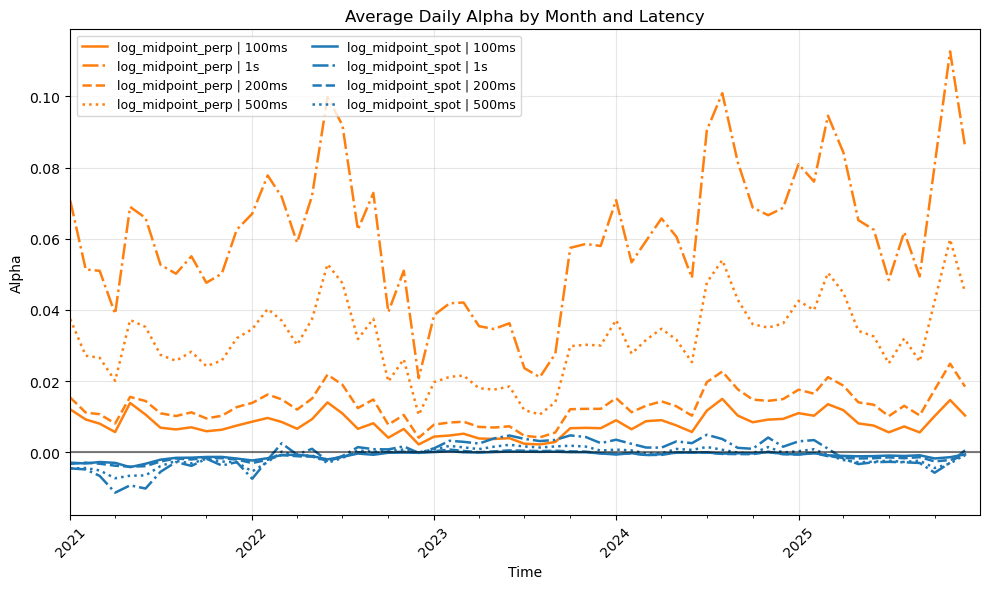

In [ ]:
import matplotlib.dates as mdates

# pivot
df_plot = alpha_table.pivot_table(
    index='yymm',
    columns=['series', 'latency'],
    values='avg_daily_alpha'
)

# convert index to datetime (time series)
df_plot.index = pd.to_datetime(df_plot.index, format='%y%m')
df_plot = df_plot.sort_index()

# plotting 
fig, ax = plt.subplots(figsize=(10, 6))

# color by series, linestyle by latency
colors = {
    'log_midpoint_spot': 'tab:blue',
    'log_midpoint_perp': 'tab:orange'
}

linestyles = {
    '100ms': '-',
    '200ms': '--',
    '500ms': ':',
    '1s': '-.'
}

# plot each line
for (series, latency) in df_plot.columns:
    ax.plot(
        df_plot.index,
        df_plot[(series, latency)],
        label=f"{series} | {latency}",
        color=colors[series],
        linestyle=linestyles[latency],
        linewidth=1.8
    )

ax.axhline(y=0, color='k', alpha=0.5)

# format x-axis as proper time series 
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
ax.set_xlim(datetime.datetime(2021,1,1), datetime.datetime(2025,12,31))

plt.xticks(rotation=45)

# labels / legend
ax.set_title("Average Daily Alpha by Month and Latency")
ax.set_xlabel("Time")
ax.set_ylabel("Alpha")

ax.legend(ncol=2, fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

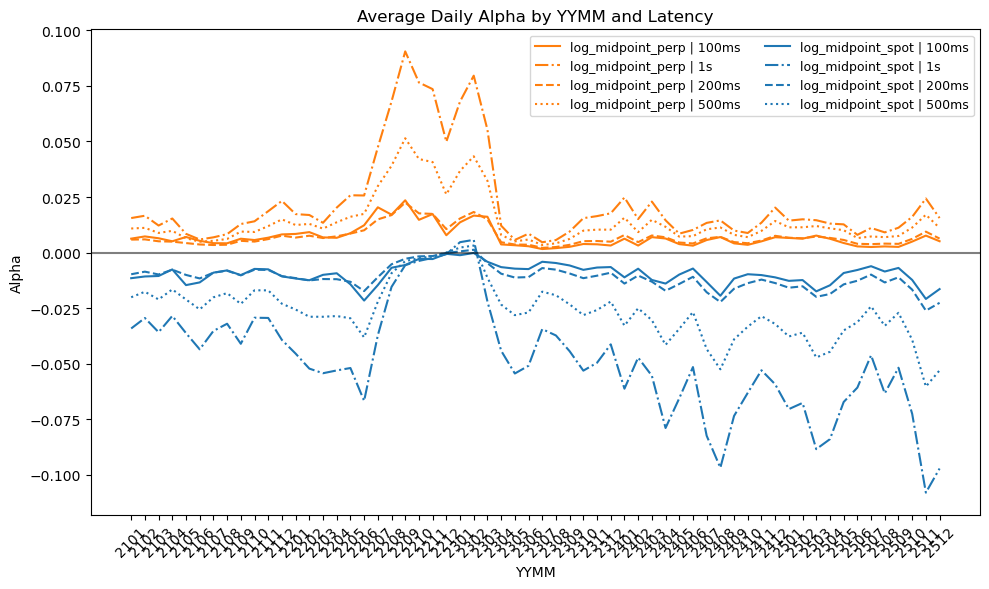

In [ ]:
import matplotlib.dates as mdates

# pivot
df_plot = alpha_table.pivot_table(
    index='yymm',
    columns=['series', 'latency'],
    values='avg_daily_alpha'
)

# convert index to datetime (time series)
df_plot.index = pd.to_datetime(df_plot.index, format='%y%m')
df_plot = df_plot.sort_index()

# plotting
fig, ax = plt.subplots(figsize=(10, 6))

# color by series, linestyle by latency
colors = {
    'log_midpoint_spot': 'tab:blue',
    'log_midpoint_perp': 'tab:orange'
}

linestyles = {
    '100ms': '-',
    '200ms': '--',
    '500ms': '-.',
    '1s': ':'
}

# plot each line
for (series, latency) in df_plot.columns:
    ax.plot(
        df_plot.index,
        df_plot[(series, latency)],
        label=f"{series} | {latency}",
        color=colors[series],
        linestyle=linestyles[latency],
        linewidth=1.8
    )

ax.axhline(y=0, color='k', alpha=0.5)

# --- format x-axis as proper time series ---
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))

ax.xaxis.set_minor_locator(mdates.MonthLocator(interval=3))
ax.set_xlim(datetime.datetime(2021,1,1), datetime.datetime(2025,12,31))

plt.xticks(rotation=45)

# --- labels / legend ---
ax.set_title("Average Daily Alpha by Month and Latency")
ax.set_xlabel("Time")
ax.set_ylabel("Alpha")

ax.legend(ncol=2, fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Processing for log-distributed lag base robustness check

In [18]:
periods = [
    ('20210101', '20220101'),
    ('20220701', '20230301'),
    ('20250101', '20251231')
]
averages = find_period_mean(results_dict, periods)

In [19]:
averages = pd.concat(averages).sort_values(['period', 'latency', 'base'])
averages[averages['series']=='log_midpoint_spot']

,series,CS,HIS_lower,HIS_upper,HIS_mid,ILS_mid,latency,base,period
1,log_midpoint_spot,0.788299,0.933224,0.821395,0.877309,0.696397,100ms,1,"20210101,20220101"
1,log_midpoint_spot,0.786234,0.935681,0.822943,0.879312,0.698146,100ms,2,"20210101,20220101"
1,log_midpoint_spot,0.779228,0.937382,0.822295,0.879839,0.697356,100ms,5,"20210101,20220101"
1,log_midpoint_spot,0.786325,0.943085,0.830428,0.886756,0.699678,100ms,10,"20210101,20220101"
1,log_midpoint_spot,0.943167,0.971068,0.602925,0.786997,0.433311,1s,1,"20210101,20220101"
1,log_midpoint_spot,0.931551,0.973012,0.601435,0.787224,0.425329,1s,2,"20210101,20220101"
1,log_midpoint_spot,0.927226,0.975790,0.603115,0.789452,0.412873,1s,5,"20210101,20220101"
1,log_midpoint_spot,0.914850,0.979472,0.603494,0.791483,0.395636,1s,10,"20210101,20220101"
1,log_midpoint_spot,0.831193,0.950987,0.776918,0.863953,0.614260,200ms,1,"20210101,20220101"
1,log_midpoint_spot,0.827974,0.953489,0.777838,0.865664,0.610506,200ms,2,"20210101,20220101"


Plotting the previous results

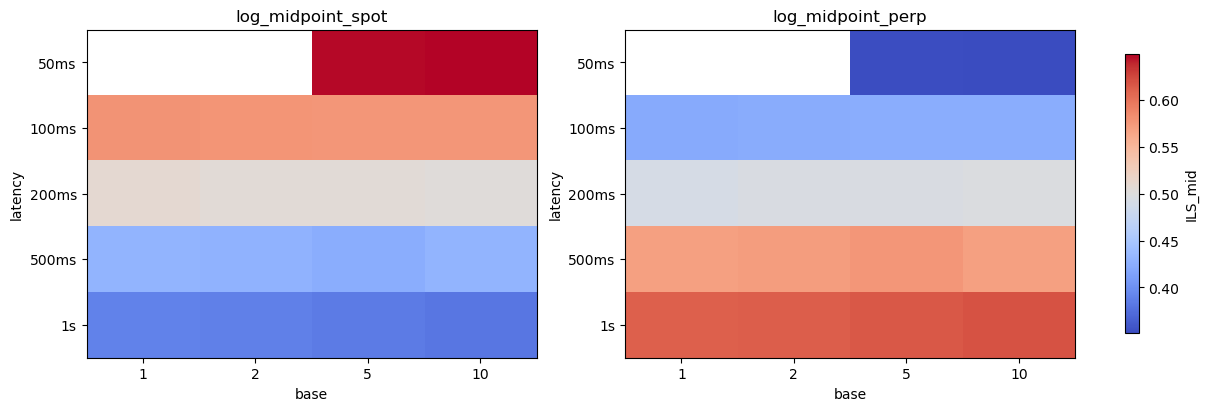

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = averages[averages['period']=='20250101,20251231']
# make latency ordered
latency_order = ['50ms', '100ms', '200ms', '500ms', '1s']
df['latency'] = pd.Categorical(df['latency'], categories=latency_order, ordered=True)

metric = "ILS_mid"

max_dev = (df[metric] - 0.5).abs().max()

vmin = 0.5 - max_dev
vmax = 0.5 + max_dev

fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

for ax, series in zip(axes, ['log_midpoint_spot', 'log_midpoint_perp']):
    sub = df[df['series'] == series].copy()
    pivot = sub.pivot(index='latency', columns='base', values=metric).sort_index()

    im = ax.imshow(
        pivot.values,
        aspect='auto',
        vmin=vmin,
        vmax=vmax,
        cmap='coolwarm'
    )

    ax.set_title(series)
    ax.set_xlabel('base')
    ax.set_ylabel('latency')
    ax.set_xticks(range(len(pivot.columns)))
    ax.set_xticklabels(pivot.columns)
    ax.set_yticks(range(len(pivot.index)))
    ax.set_yticklabels(pivot.index)

fig.colorbar(im, ax=axes, shrink=0.85, label=metric)
plt.show()

Intraday error correction

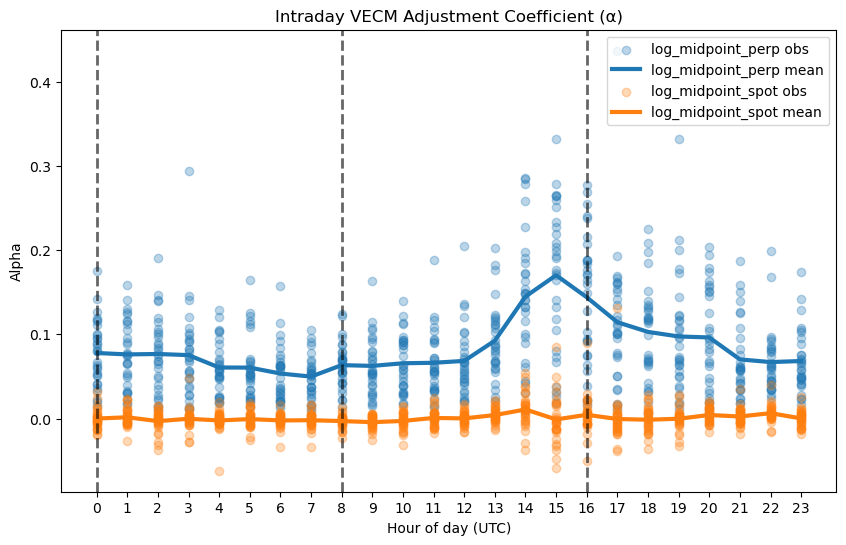

In [7]:
df = results[('1s', 1)].copy()
# ensure datetime
df['interval'] = pd.to_datetime(df['interval'])
# df['alpha'] = df['alpha'].abs()

# extract hour of day
df['hour'] = df['interval'].dt.hour

# mean alpha by hour and series
mean_alpha = (
    df.groupby(['hour','series'])['alpha']
      .mean()
      .reset_index()
)

fig, ax = plt.subplots(figsize=(10,6))

for series, g in df.groupby('series'):
    
    # scatter observations
    ax.scatter(
        g['hour'],
        g['alpha'],
        alpha=0.3,
        label=f"{series} obs"
    )
    
    # mean line
    m = mean_alpha[mean_alpha['series'] == series]
    ax.plot(
        m['hour'],
        m['alpha'],
        linewidth=3,
        label=f"{series} mean"
    )

# funding payment times
funding_times = [0, 8, 16]

for f in funding_times:
    ax.axvline(
        x=f,
        linestyle='--',
        linewidth=2,
        alpha=0.6,
        color='k'
    )

ax.set_xlabel("Hour of day (UTC)")
ax.set_ylabel("Alpha")
ax.set_title("Intraday VECM Adjustment Coefficient (α)")
ax.set_xticks(range(24))
ax.legend()

plt.show()

Checking proportion of CS > 0

In [14]:
results_i = results_dict[('1s', 1)].copy()
# pivot to get both CS values in one row
cs_wide = results_i.pivot(index='interval', columns='series', values='CS')

# check condition: both > 0
both_positive = (cs_wide > 0).all(axis=1)

# portion of intervals
portion = both_positive.mean()

print(portion)

0.698329974752739


HIS plot

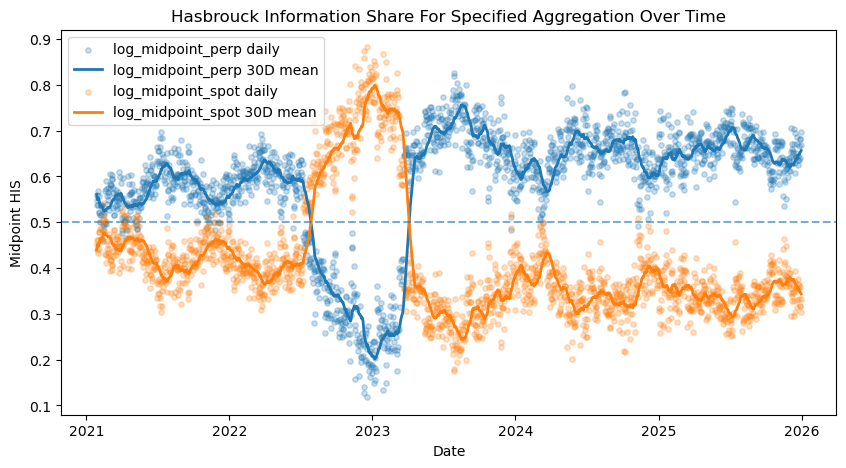

In [20]:
# results_i = results_dict[('1s', 1)].copy()
# # pivot to get both CS values in one row
# cs_wide = results_i.pivot(index='interval', columns='series', values='CS')

# # check condition: both > 0
# both_positive = (cs_wide > 0).all(axis=1)

# # portion of intervals
# portion = both_positive.mean()

results_i = results_dict[('1s', 1)].copy()
results_i['interval'] = pd.to_datetime(results_i['interval'])
results_i['date'] = results_i['interval'].dt.date
results_i = results_i[results_i['interval'].isin(both_positive.index)]

daily = (
    results_i.groupby(['series', 'date'], as_index=False)['HIS_mid']
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 5))

window = 30  # days

for series, df_s in daily.groupby('series'):
    df_s = df_s.sort_values('date').copy()

    ax.scatter(df_s['date'], df_s['HIS_mid'], alpha=0.25, s=15, label=f'{series} daily')
    ax.plot(
        df_s['date'],
        df_s['HIS_mid'].rolling(window=window, min_periods=1).mean(),
        linewidth=2,
        label=f'{series} {window}D mean'
    )

ax.axhline(0.5, linestyle='--', alpha=0.6)
ax.set_xlabel('Date')
ax.set_ylabel('Midpoint HIS')
ax.legend()
plt.title('Hasbrouck Information Share For Specified Aggregation Over Time')
plt.show()

ILS plot

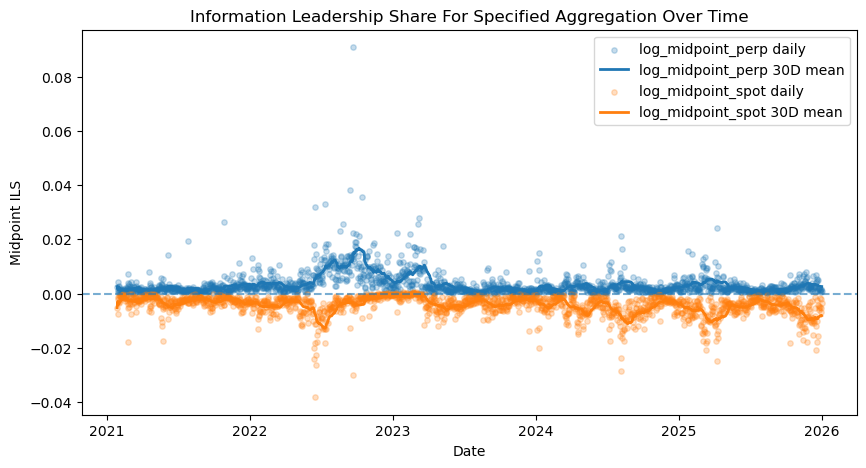

In [18]:
results_i = results_dict[('100ms', 10)].copy()
results_i['interval'] = pd.to_datetime(results_i['interval'])
results_i['date'] = results_i['interval'].dt.date

daily = (
    results_i.groupby(['series', 'date'], as_index=False)['alpha']
    .mean()
)

fig, ax = plt.subplots(figsize=(10, 5))

window = 30  # days

for series, df_s in daily.groupby('series'):
    df_s = df_s.sort_values('date').copy()

    ax.scatter(df_s['date'], df_s['alpha'], alpha=0.25, s=15, label=f'{series} daily')
    ax.plot(
        df_s['date'],
        df_s['alpha'].rolling(window=window, min_periods=1).mean(),
        linewidth=2,
        label=f'{series} {window}D mean'
    )

ax.axhline(0, linestyle='--', alpha=0.6)
ax.set_xlabel('Date')
ax.set_ylabel('Midpoint ILS')
ax.legend()
plt.title('Information Leadership Share For Specified Aggregation Over Time')
plt.show()